# LA Mayoral Primary Model

This notebook estimates the probability that Spencer Pratt finishes second in the Los Angeles mayoral primary by simulating the distribution of ballots that have not yet been counted.

The model is scenario-based. It is not a prediction, and it is based on assumptions that can be modified in the cells. 

The central calculation is:

```text
final candidate votes = current candidate votes + simulated share of remaining votes * remaining votes
```

The model ignores pre-voting polling and uses the singular vote share release as a baseline, where future releases are characterized as "post-baseline" updates. 

Before post-baseline vote updates exist, the simulated remaining-vote shares start from the current counted vote share with editable fallback tilt assumptions applied (these can be edited). Once a second vote row exists, the model switches to aggregate observed post-baseline votes: the candidate-level delta between the first vote row and the latest vote row. In observed-update mode, aggregate late-vote shares are used as the simulation mean by default, and observed late/baseline multipliers are displayed as diagnostics.

## Core Assumption

Future uncounted ballots will resemble the aggregate composition of previously observed post-baseline ballots, subject to modeled uncertainty. The assumptions used in the late ballot tilt presume that late ballots will disproportionately accrue to the Democratic candidates.

```text
Observed late ballots
        -> estimate late-ballot composition
        -> assume future ballots resemble that composition
        -> simulate uncertainty
```

An optional trend extrapolation control can further tilt future remaining ballots in the direction of the observed late-vote multiplier, but it defaults to neutral.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 120,
})

## Data

The notebook treats `votes.csv` as the raw election input. Vote rows are cumulative snapshots over time.

The first row is the stable baseline snapshot. The bottom row is the latest release.

In [2]:
VOTE_COLUMNS = ["Date", "Bass", "Pratt", "Raman", "Other", "Counted Percentage of Total"]

votes = pd.read_csv("votes.csv")

missing_vote_cols = sorted(set(VOTE_COLUMNS) - set(votes.columns))
if missing_vote_cols:
    raise ValueError(f"votes.csv is missing required columns: {missing_vote_cols}")

votes = votes.copy().reset_index(drop=True)
votes["Date"] = pd.to_datetime(votes["Date"])

for candidate in ["Bass", "Pratt", "Raman", "Other"]:
    votes[candidate] = pd.to_numeric(votes[candidate], errors="raise")

votes["Counted Percentage of Total"] = pd.to_numeric(
    votes["Counted Percentage of Total"], errors="raise"
)

print(f"Loaded {len(votes):,} vote snapshot(s).")

Loaded 1 vote snapshot(s).


## Latest Vote Snapshot and Late-Count Baseline

The bottom vote-count row is the current state of the race. The first vote-count row is the stable baseline snapshot.

When new rows are appended, the observed late-count baseline is the aggregate candidate-level vote delta between the first row and the latest row. Per-update batch shares are retained as diagnostics and to estimate uncertainty.

With only one vote row, there are no observed update batches yet, so the model falls back to current counted vote share plus editable fallback tilt assumptions.

In [3]:
candidates = ["Bass", "Pratt", "Raman", "Other"]

baseline_snapshot = votes.iloc[0]
latest = votes.iloc[-1]

bass_votes = float(latest["Bass"])
pratt_votes = float(latest["Pratt"])
raman_votes = float(latest["Raman"])
other_votes = float(latest["Other"])
counted_pct = float(latest["Counted Percentage of Total"])

if not (0 < counted_pct <= 1):
    raise ValueError("Counted Percentage of Total must be expressed as a decimal between 0 and 1.")

vote_snapshots = votes[candidates].astype(float)
current_vote_values = np.array([bass_votes, pratt_votes, raman_votes, other_votes], dtype=float)
baseline_vote_values = baseline_snapshot[candidates].astype(float).to_numpy()
late_count_delta_values = current_vote_values - baseline_vote_values
update_batch_deltas = vote_snapshots.diff().iloc[1:]

if (late_count_delta_values < -1e-8).any():
    raise ValueError("Vote totals should be cumulative. The latest row is below the baseline row for at least one candidate.")
if (update_batch_deltas < -1e-8).any().any():
    raise ValueError("Vote totals should be cumulative. At least one update row is below the prior row.")

update_batch_totals = update_batch_deltas.sum(axis=1)
valid_update_batches = update_batch_deltas.loc[update_batch_totals > 0].copy()
valid_update_batch_totals = valid_update_batches.sum(axis=1)
update_batch_shares = valid_update_batches.div(valid_update_batch_totals, axis=0)

total_counted = current_vote_values.sum()
baseline_total_counted = baseline_vote_values.sum()
observed_late_counted_votes = late_count_delta_values.sum()
estimated_total_votes = total_counted / counted_pct
remaining_votes = estimated_total_votes - total_counted

current_share = pd.Series(current_vote_values / total_counted, index=candidates)
baseline_share = pd.Series(baseline_vote_values / baseline_total_counted, index=candidates)
if observed_late_counted_votes > 0:
    aggregate_late_vote_share = pd.Series(late_count_delta_values / observed_late_counted_votes, index=candidates)
else:
    aggregate_late_vote_share = pd.Series(np.nan, index=candidates)

if len(update_batch_shares) > 0:
    batch_mean_share = update_batch_shares.mean(axis=0)
    batch_median_share = update_batch_shares.median(axis=0)
    batch_std_share = update_batch_shares.std(axis=0, ddof=1) if len(update_batch_shares) >= 2 else pd.Series(np.nan, index=candidates)
    batch_cv_share = batch_std_share / batch_mean_share.replace(0, np.nan)
else:
    batch_mean_share = pd.Series(np.nan, index=candidates)
    batch_median_share = pd.Series(np.nan, index=candidates)
    batch_std_share = pd.Series(np.nan, index=candidates)
    batch_cv_share = pd.Series(np.nan, index=candidates)

current_vote_table = pd.DataFrame({
    "Candidate": candidates,
    "Baseline Votes": baseline_vote_values,
    "Current Votes": current_vote_values,
    "Votes Added Since Baseline": late_count_delta_values,
    "Current Share of Counted Votes": current_share.values,
    "Aggregate Late-Vote Share": aggregate_late_vote_share.reindex(candidates).values,
})

summary_table = pd.DataFrame({
    "Metric": [
        "Baseline update",
        "Latest update",
        "Counted percentage",
        "Baseline counted votes",
        "Current counted votes",
        "Votes added since baseline",
        "Post-baseline update batches",
        "Estimated total votes",
        "Estimated remaining votes",
    ],
    "Value": [
        baseline_snapshot["Date"].strftime("%Y-%m-%d %H:%M"),
        latest["Date"].strftime("%Y-%m-%d %H:%M"),
        f"{counted_pct:.1%}",
        f"{baseline_total_counted:,.0f}",
        f"{total_counted:,.0f}",
        f"{observed_late_counted_votes:,.0f}",
        f"{len(update_batch_shares):,}",
        f"{estimated_total_votes:,.0f}",
        f"{remaining_votes:,.0f}",
    ],
})

display(summary_table)
display(
    current_vote_table.style.format({
        "Baseline Votes": "{:,.0f}",
        "Current Votes": "{:,.0f}",
        "Votes Added Since Baseline": "{:,.0f}",
        "Current Share of Counted Votes": "{:.1%}",
        "Aggregate Late-Vote Share": "{:.1%}",
    }, na_rep="-")
)

if len(update_batch_shares) > 0:
    update_batch_table = votes.loc[update_batch_shares.index, ["Date"]].reset_index(drop=True)
    update_batch_table["Batch Votes"] = valid_update_batch_totals.to_numpy()
    for candidate in candidates:
        update_batch_table[f"{candidate} Batch Share"] = update_batch_shares[candidate].to_numpy()
    display(
        update_batch_table.style.format({
            "Batch Votes": "{:,.0f}",
            **{f"{candidate} Batch Share": "{:.1%}" for candidate in candidates},
        })
    )

    batch_stability_table = pd.DataFrame({
        "Candidate": candidates,
        "Aggregate Late-Vote Share": aggregate_late_vote_share.reindex(candidates).values,
        "Mean Batch Share": batch_mean_share.reindex(candidates).values,
        "Median Batch Share": batch_median_share.reindex(candidates).values,
        "Batch Share Std. Dev.": batch_std_share.reindex(candidates).values,
        "Batch Share Coef. Variation": batch_cv_share.reindex(candidates).values,
    })
    display(
        batch_stability_table.style.format({
            "Aggregate Late-Vote Share": "{:.1%}",
            "Mean Batch Share": "{:.1%}",
            "Median Batch Share": "{:.1%}",
            "Batch Share Std. Dev.": "{:.1%}",
            "Batch Share Coef. Variation": "{:.2f}",
        }, na_rep="-")
    )

,Metric,Value
0,Baseline update,2026-06-03 20:52
1,Latest update,2026-06-03 20:52
2,Counted percentage,62.0%
3,Baseline counted votes,"525,326"
4,Current counted votes,"525,326"
5,Votes added since baseline,0
6,Post-baseline update batches,0
7,Estimated total votes,"847,300"
8,Estimated remaining votes,"321,974"


,Candidate,Baseline Votes,Current Votes,Votes Added Since Baseline,Current Share of Counted Votes,Aggregate Late-Vote Share
0,Bass,"183,701","183,701",0,35.0%,-
1,Pratt,"157,116","157,116",0,29.9%,-
2,Raman,"119,809","119,809",0,22.8%,-
3,Other,"64,700","64,700",0,12.3%,-


## Remaining-Vote Baseline and Late-Ballot Tilt

The model uses a simple no-polling update rule:

- If `votes.csv` has one row, the remaining-vote baseline is the current counted vote share. In this fallback mode, candidate-specific tilt assumptions create the simulated remaining-vote distributions.
- If `votes.csv` has more than one row, the remaining-vote baseline is the aggregate post-baseline late-vote share: latest cumulative votes minus first-row baseline votes. In observed-update mode, those shares are used as the default simulation mean.

When post-baseline updates exist, the notebook derives observed late/baseline multipliers:

```text
observed multiplier = aggregate late-vote share / baseline counted share
```

Those multipliers are displayed as diagnostics. An optional trend extrapolation can apply those observed multipliers again to the future remaining-vote center, but the default strength is `0.0`, meaning no extra extrapolation.

In [4]:
# Candidate-specific late-ballot multipliers used only before post-baseline update rows exist.
# Once vote updates exist, observed late-vote shares replace these fallback controls by default.
late_vote_tilt = {
    "Bass": {"median_multiplier": 1.2, "log_sigma": 0.2, "skew": 0.25},
    "Pratt": {"median_multiplier": 0.75, "log_sigma": 0.3, "skew": -0.25},
    "Raman": {"median_multiplier": 1.3, "log_sigma": 0.3, "skew": 0.25},
    "Other": {"median_multiplier": 0.4, "log_sigma": 0.2, "skew": -0.5},
}

# Optional post-baseline extrapolation.
# 0.0 = use observed aggregate late-vote shares directly.
# 0.5 = partially extend the observed late/baseline tilt.
# 1.0 = fully apply the observed late/baseline multiplier again.
LATE_TREND_STRENGTH = 0.0

In [5]:
N_SIMS = 100_000
RANDOM_SEED = 42

# Dirichlet uncertainty controls used once post-baseline update batches exist.
# Concentration is estimated from batch-size-weighted batch-to-batch variance when at least two batches exist.
SINGLE_UPDATE_BATCH_CONCENTRATION = 50
MIN_UPDATE_BATCH_CONCENTRATION = 25
MAX_UPDATE_BATCH_CONCENTRATION = 2_000
DIRICHLET_EPSILON = 1e-6

assert LATE_TREND_STRENGTH >= 0, "LATE_TREND_STRENGTH must be non-negative"
assert SINGLE_UPDATE_BATCH_CONCENTRATION > 0, "SINGLE_UPDATE_BATCH_CONCENTRATION must be positive"
assert MIN_UPDATE_BATCH_CONCENTRATION > 0, "MIN_UPDATE_BATCH_CONCENTRATION must be positive"
assert MAX_UPDATE_BATCH_CONCENTRATION >= MIN_UPDATE_BATCH_CONCENTRATION, "MAX_UPDATE_BATCH_CONCENTRATION must be >= MIN_UPDATE_BATCH_CONCENTRATION"
assert DIRICHLET_EPSILON > 0, "DIRICHLET_EPSILON must be positive"

for candidate in candidates:
    params = late_vote_tilt[candidate]
    assert params["median_multiplier"] > 0, "median_multiplier must be positive"
    assert params["log_sigma"] >= 0, "log_sigma must be non-negative"
    assert -0.95 <= params["skew"] <= 0.95, "skew should stay between -0.95 and 0.95"

use_observed_update_batches = observed_late_counted_votes > 0
if use_observed_update_batches:
    baseline_source = "Aggregate post-baseline late-vote distribution"
    simulation_method = "Dirichlet around aggregate late-vote shares; fallback multipliers ignored"
    remaining_vote_baseline_share = aggregate_late_vote_share.copy()
else:
    baseline_source = "Fallback current counted vote share"
    simulation_method = "Skewed multiplier model applied to current counted share"
    remaining_vote_baseline_share = current_share.copy()

remaining_vote_baseline_share = remaining_vote_baseline_share / remaining_vote_baseline_share.sum()
remaining_vote_baseline_vec = remaining_vote_baseline_share.reindex(candidates).to_numpy(dtype=float)

tilt_median_vec = np.array([late_vote_tilt[c]["median_multiplier"] for c in candidates], dtype=float)
fallback_tilt_weights = current_share.reindex(candidates).to_numpy(dtype=float) * tilt_median_vec
fallback_median_tilt_share = pd.Series(
    fallback_tilt_weights / fallback_tilt_weights.sum(),
    index=candidates,
)

if use_observed_update_batches:
    observed_late_multiplier = remaining_vote_baseline_share / baseline_share.replace(0, np.nan)
    observed_late_multiplier = observed_late_multiplier.replace([np.inf, -np.inf], np.nan)
    late_vote_tilt_index = np.log(observed_late_multiplier).clip(-0.95, 0.95)
    trend_multiplier = observed_late_multiplier.fillna(1.0) ** LATE_TREND_STRENGTH
    simulation_center_weights = remaining_vote_baseline_share * trend_multiplier
    simulation_center_share = simulation_center_weights / simulation_center_weights.sum()
else:
    observed_late_multiplier = pd.Series(np.nan, index=candidates)
    late_vote_tilt_index = pd.Series(np.nan, index=candidates)
    trend_multiplier = pd.Series(1.0, index=candidates)
    simulation_center_share = fallback_median_tilt_share.copy()

simulation_center_vec = simulation_center_share.reindex(candidates).to_numpy(dtype=float)


def draw_skewed_log_multipliers(rng, size, candidate_order):
    z = rng.normal(size=(size, len(candidate_order)))
    transformed = np.empty_like(z)

    for idx, candidate in enumerate(candidate_order):
        skew = late_vote_tilt[candidate]["skew"]
        tail_stretch = 1 + abs(skew)
        opposite_shrink = 1 / tail_stretch

        if skew >= 0:
            transformed[:, idx] = np.where(z[:, idx] >= 0, z[:, idx] * tail_stretch, z[:, idx] * opposite_shrink)
        else:
            transformed[:, idx] = np.where(z[:, idx] < 0, z[:, idx] * tail_stretch, z[:, idx] * opposite_shrink)

    medians = np.array([late_vote_tilt[c]["median_multiplier"] for c in candidate_order], dtype=float)
    log_sigmas = np.array([late_vote_tilt[c]["log_sigma"] for c in candidate_order], dtype=float)
    return medians * np.exp(transformed * log_sigmas)


def dirichlet_alpha_from_mean(mean_vec, concentration):
    safe_mean = np.clip(np.asarray(mean_vec, dtype=float), DIRICHLET_EPSILON, None)
    safe_mean = safe_mean / safe_mean.sum()
    return safe_mean * concentration


def estimate_dirichlet_concentration(mean_share, batch_shares, batch_weights):
    if len(batch_shares) < 2:
        return SINGLE_UPDATE_BATCH_CONCENTRATION, "Fallback: fewer than 2 update batches"

    weights = pd.Series(batch_weights, index=batch_shares.index, dtype=float)
    weights = weights / weights.sum()
    centered_batch_shares = batch_shares.subtract(mean_share, axis=1)
    batch_variance = centered_batch_shares.pow(2).mul(weights, axis=0).sum(axis=0)

    effective_batch_count = 1 / np.square(weights).sum()
    if effective_batch_count > 1:
        batch_variance = batch_variance * (effective_batch_count / (effective_batch_count - 1))

    estimates = []
    for candidate in candidates:
        mu = float(mean_share[candidate])
        var = float(batch_variance[candidate])
        if DIRICHLET_EPSILON < mu < 1 - DIRICHLET_EPSILON and var > 0:
            estimate = (mu * (1 - mu) / var) - 1
            if np.isfinite(estimate) and estimate > 0:
                estimates.append(estimate)

    if not estimates:
        return MAX_UPDATE_BATCH_CONCENTRATION, "Fallback: no measurable batch variance"

    raw_estimate = float(np.median(estimates))
    clipped_estimate = float(np.clip(raw_estimate, MIN_UPDATE_BATCH_CONCENTRATION, MAX_UPDATE_BATCH_CONCENTRATION))
    return clipped_estimate, "Estimated from batch-size-weighted candidate variance"


if use_observed_update_batches:
    update_batch_concentration, concentration_source = estimate_dirichlet_concentration(
        remaining_vote_baseline_share,
        update_batch_shares,
        valid_update_batch_totals,
    )
else:
    update_batch_concentration = np.nan
    concentration_source = "Not used before post-baseline update batches exist"

baseline_update_table = pd.DataFrame({
    "Candidate": candidates,
    "Current Counted Share": current_share.reindex(candidates).values,
    "Aggregate Late-Vote Share": aggregate_late_vote_share.reindex(candidates).values,
    "Remaining-Vote Baseline Share": remaining_vote_baseline_share.reindex(candidates).values,
    "Observed Late/Baseline Multiplier": observed_late_multiplier.reindex(candidates).values,
    "Late-Vote Tilt Index": late_vote_tilt_index.reindex(candidates).values,
    "Post-Baseline Trend Multiplier": trend_multiplier.reindex(candidates).values,
    "Fallback Median-Tilt Share": fallback_median_tilt_share.reindex(candidates).values,
    "Simulation Center Share": simulation_center_share.reindex(candidates).values,
})

baseline_source_table = pd.DataFrame({
    "Model Input": [
        "Remaining-vote baseline source",
        "Simulation method",
        "Late trend strength",
        "Post-baseline update batches",
        "Update-batch concentration",
        "Concentration source",
    ],
    "Value": [
        baseline_source,
        simulation_method,
        f"{LATE_TREND_STRENGTH:.2f}",
        f"{len(update_batch_shares):,}",
        "-" if pd.isna(update_batch_concentration) else f"{update_batch_concentration:,.0f}",
        concentration_source,
    ],
})

display(baseline_source_table)
display(
    baseline_update_table.style.format({
        "Current Counted Share": "{:.1%}",
        "Aggregate Late-Vote Share": "{:.1%}",
        "Remaining-Vote Baseline Share": "{:.1%}",
        "Observed Late/Baseline Multiplier": "{:.2f}",
        "Late-Vote Tilt Index": "{:+.2f}",
        "Post-Baseline Trend Multiplier": "{:.2f}",
        "Fallback Median-Tilt Share": "{:.1%}",
        "Simulation Center Share": "{:.1%}",
    }, na_rep="-")
)

,Model Input,Value
0,Remaining-vote baseline source,Fallback current counted vote share
1,Simulation method,Skewed multiplier model applied to current cou...
2,Late trend strength,0.00
3,Post-baseline update batches,0
4,Update-batch concentration,-
5,Concentration source,Not used before post-baseline update batches e...


,Candidate,Current Counted Share,Aggregate Late-Vote Share,Remaining-Vote Baseline Share,Observed Late/Baseline Multiplier,Late-Vote Tilt Index,Post-Baseline Trend Multiplier,Fallback Median-Tilt Share,Simulation Center Share
0,Bass,35.0%,-,35.0%,-,-,1.00,42.4%,42.4%
1,Pratt,29.9%,-,29.9%,-,-,1.00,22.7%,22.7%
2,Raman,22.8%,-,22.8%,-,-,1.00,30.0%,30.0%
3,Other,12.3%,-,12.3%,-,-,1.00,5.0%,5.0%


## Remaining-Vote Share Simulation

If only one vote row exists, each simulation draws candidate-specific late-ballot multipliers, applies them to the current counted vote share, and normalizes the adjusted weights into remaining-vote shares.

Once post-baseline vote updates exist, the model stops using fallback multipliers. It uses aggregate late-vote shares as the default mean of a Dirichlet distribution. If `LATE_TREND_STRENGTH` is above zero, the observed late/baseline multiplier nudges that mean farther in the observed late-vote direction before simulation.

In [6]:
rng = np.random.default_rng(RANDOM_SEED)

if use_observed_update_batches:
    late_vote_multipliers = None
    observed_alpha = dirichlet_alpha_from_mean(simulation_center_vec, update_batch_concentration)
    simulated_remaining_shares = rng.dirichlet(observed_alpha, size=N_SIMS)
else:
    late_vote_multipliers = draw_skewed_log_multipliers(rng, N_SIMS, candidates)
    adjusted_weights = late_vote_multipliers * current_share.reindex(candidates).to_numpy(dtype=float)
    simulated_remaining_shares = adjusted_weights / adjusted_weights.sum(axis=1, keepdims=True)

sim_shares = pd.DataFrame(simulated_remaining_shares, columns=candidates)
simulated_mean_remaining_share = sim_shares.mean()
simulated_median_remaining_share = sim_shares.median()

remaining_share_summary = sim_shares.agg([
    "mean",
    "median",
    lambda x: x.quantile(0.05),
    lambda x: x.quantile(0.95),
])
remaining_share_summary.index = ["Mean", "Median", "5th Percentile", "95th Percentile"]

if late_vote_multipliers is not None:
    multiplier_summary = pd.DataFrame(late_vote_multipliers, columns=candidates).agg([
        "mean",
        "median",
        lambda x: x.quantile(0.05),
        lambda x: x.quantile(0.95),
    ]).rename(index={"<lambda>": "quantile"})
    multiplier_summary.index = ["Mean", "Median", "5th Percentile", "95th Percentile"]
    print("Fallback late-ballot multiplier summary")
    display(multiplier_summary.style.format("{:.2f}"))
else:
    print("Post-baseline update batches exist: fallback multiplier/skew assumptions are not applied.")

print("Simulated remaining-vote share summary")
display(remaining_share_summary.style.format("{:.1%}"))

Fallback late-ballot multiplier summary


,Bass,Pratt,Raman,Other
Mean,1.27,0.75,1.44,0.38
Median,1.20,0.75,1.30,0.40
5th Percentile,0.92,0.40,0.88,0.24
95th Percentile,1.81,1.12,2.40,0.50


Simulated remaining-vote share summary


,Bass,Pratt,Raman,Other
Mean,42.8%,21.4%,31.2%,4.6%
Median,42.5%,21.4%,30.1%,4.6%
5th Percentile,31.7%,12.3%,20.7%,2.8%
95th Percentile,54.8%,31.0%,45.0%,6.5%


## Simulated Final Vote Totals

Each simulation converts the modeled remaining-vote shares into remaining-vote counts, adds those counts to the current vote totals, and ranks the candidates by final vote total.

In [7]:
simulated_remaining_votes = simulated_remaining_shares * remaining_votes
simulated_final_votes = current_vote_values + simulated_remaining_votes
final_votes = pd.DataFrame(simulated_final_votes, columns=candidates)

ranks = final_votes.rank(axis=1, ascending=False, method="min")
pratt_second = ranks["Pratt"] == 2
raman_second = ranks["Raman"] == 2
bass_first = ranks["Bass"] == 1
pratt_beats_raman = final_votes["Pratt"] > final_votes["Raman"]

headline_probabilities = pd.Series({
    "P(Pratt finishes second)": pratt_second.mean(),
    "P(Raman finishes second)": raman_second.mean(),
    "P(Bass finishes first)": bass_first.mean(),
})

headline_probabilities.to_frame("Probability").style.format({"Probability": "{:.1%}"})

,Probability
P(Pratt finishes second),59.2%
P(Raman finishes second),39.1%
P(Bass finishes first),98.3%


## Headline Result

The headline probability is the share of simulations in which Pratt's final rank is exactly second. The margin range below is a modeled 5th-95th percentile range under the stated assumptions, not a formal confidence interval.

In [8]:
pratt_raman_margin = final_votes["Pratt"] - final_votes["Raman"]
margin_summary = pd.Series({
    "Mean Pratt-Raman final margin": pratt_raman_margin.mean(),
    "Median Pratt-Raman final margin": pratt_raman_margin.median(),
    "5th percentile margin": pratt_raman_margin.quantile(0.05),
    "95th percentile margin": pratt_raman_margin.quantile(0.95),
})

headline_markdown = (
    "### Model Result\n\n"
    f"**Pratt second-place probability:** {pratt_second.mean():.1%}  \n"
    f"**Raman second-place probability:** {raman_second.mean():.1%}  \n"
    f"**Pratt beats Raman:** {pratt_beats_raman.mean():.1%} of simulations  \n"
    f"**Median Pratt-Raman final margin:** {pratt_raman_margin.median():,.0f} votes  \n"
    f"**Modeled 5th-95th percentile Pratt-Raman margin range:** "
    f"{pratt_raman_margin.quantile(0.05):,.0f} to {pratt_raman_margin.quantile(0.95):,.0f} votes"
)

display(Markdown(headline_markdown))
display(margin_summary.to_frame("Votes").style.format({"Votes": "{:,.0f}"}))

### Model Result

**Pratt second-place probability:** 59.2%  
**Raman second-place probability:** 39.1%  
**Pratt beats Raman:** 59.3% of simulations  
**Median Pratt-Raman final margin:** 8,703 votes  
**Modeled 5th-95th percentile Pratt-Raman margin range:** -57,629 to 60,334 votes

,Votes
Mean Pratt-Raman final margin,"6,042"
Median Pratt-Raman final margin,"8,703"
5th percentile margin,"-57,629"
95th percentile margin,"60,334"


## Distribution of Remaining-Vote Shares

These histograms show the modeled uncertainty over remaining ballots. Dotted lines show the selected remaining-vote baseline; dashed lines show simulated mean remaining-vote shares.

When post-baseline update batches exist, the selected baseline is the aggregate late-vote share. Fallback multiplier/skew assumptions are ignored unless an explicit post-baseline trend strength is applied.

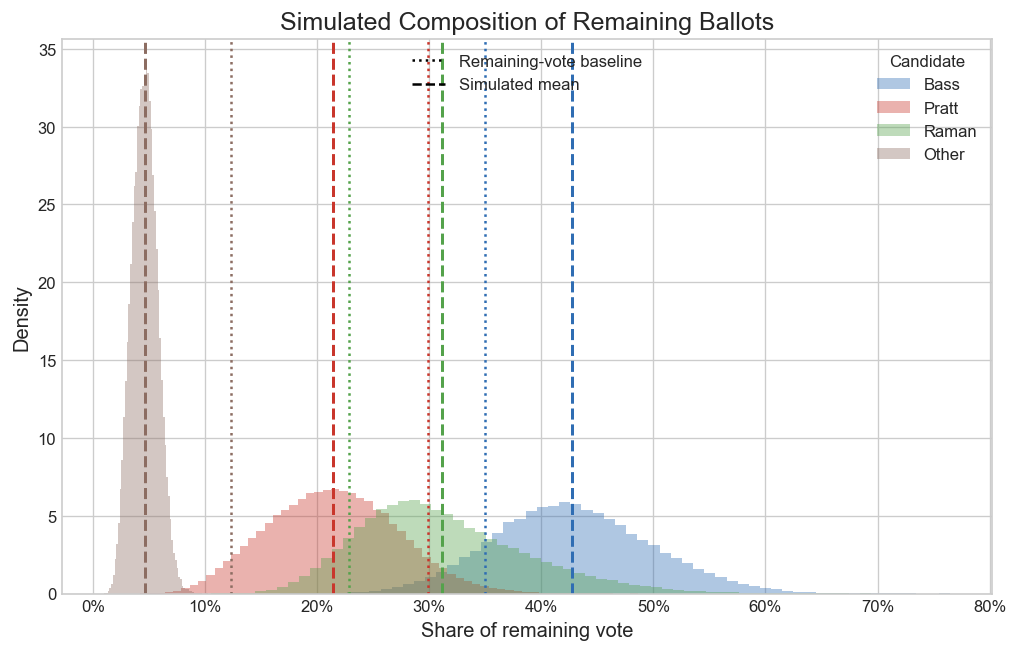

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {
    "Bass": "#2F6DB3",
    "Pratt": "#C9362C",
    "Raman": "#54A24B",
    "Other": "#8C6D62",
}

for candidate in candidates:
    ax.hist(
        sim_shares[candidate],
        bins=60,
        alpha=0.38,
        density=True,
        label=candidate,
        color=colors[candidate],
    )
    ax.axvline(remaining_vote_baseline_share[candidate], color=colors[candidate], linestyle=":", linewidth=1.5)
    ax.axvline(sim_shares[candidate].mean(), color=colors[candidate], linestyle="--", linewidth=1.8)

ax.set_title("Simulated Composition of Remaining Ballots")
ax.set_xlabel("Share of remaining vote")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

candidate_legend = ax.legend(title="Candidate", loc="upper right")
ax.add_artist(candidate_legend)
line_legend = [
    plt.Line2D([0], [0], color="black", linestyle=":", label="Remaining-vote baseline"),
    plt.Line2D([0], [0], color="black", linestyle="--", label="Simulated mean"),
]
ax.legend(handles=line_legend, loc="upper center")
plt.show()

## Pratt Share Sensitivity

This table fixes Pratt's share of the remaining ballots from 10% to 30%. For each fixed Pratt share, Bass, Raman, and Other are simulated over the non-Pratt share.

Before post-baseline vote updates exist, the non-Pratt shares use the fallback skewed multiplier model. Once update batches exist, the non-Pratt shares use a Dirichlet distribution centered on the post-baseline simulation center.

In [10]:
pratt_grid = np.arange(0.10, 0.305, 0.01)
non_pratt_candidates = ["Bass", "Raman", "Other"]
if use_observed_update_batches:
    non_pratt_baseline_vec = simulation_center_share.reindex(non_pratt_candidates).to_numpy(dtype=float)
else:
    non_pratt_baseline_vec = remaining_vote_baseline_share.reindex(non_pratt_candidates).to_numpy(dtype=float)
non_pratt_baseline_vec = non_pratt_baseline_vec / non_pratt_baseline_vec.sum()

sensitivity_rows = []
sensitivity_rng = np.random.default_rng(RANDOM_SEED + 1)

for pratt_share in pratt_grid:
    if use_observed_update_batches:
        non_pratt_alpha = dirichlet_alpha_from_mean(non_pratt_baseline_vec, update_batch_concentration)
        non_pratt_draws = sensitivity_rng.dirichlet(non_pratt_alpha, size=N_SIMS) * (1 - pratt_share)
    else:
        non_pratt_multipliers = draw_skewed_log_multipliers(sensitivity_rng, N_SIMS, non_pratt_candidates)
        non_pratt_weights = non_pratt_multipliers * non_pratt_baseline_vec
        non_pratt_draws = non_pratt_weights / non_pratt_weights.sum(axis=1, keepdims=True) * (1 - pratt_share)

    share_matrix = np.zeros((N_SIMS, len(candidates)))
    share_matrix[:, candidates.index("Pratt")] = pratt_share
    for idx, candidate in enumerate(non_pratt_candidates):
        share_matrix[:, candidates.index(candidate)] = non_pratt_draws[:, idx]

    scenario_final_votes = pd.DataFrame(
        current_vote_values + share_matrix * remaining_votes,
        columns=candidates,
    )
    scenario_ranks = scenario_final_votes.rank(axis=1, ascending=False, method="min")
    scenario_pratt_second = scenario_ranks["Pratt"] == 2
    scenario_margin = scenario_final_votes["Pratt"] - scenario_final_votes["Raman"]

    sensitivity_rows.append({
        "Pratt Remaining Vote Share": pratt_share,
        "P(Pratt Finishes Second)": scenario_pratt_second.mean(),
        "Median Pratt-Raman Final Margin": scenario_margin.median(),
        "5th Percentile Margin": scenario_margin.quantile(0.05),
        "95th Percentile Margin": scenario_margin.quantile(0.95),
    })

sensitivity_table = pd.DataFrame(sensitivity_rows)

display(
    sensitivity_table.style.format({
        "Pratt Remaining Vote Share": "{:.0%}",
        "P(Pratt Finishes Second)": "{:.1%}",
        "Median Pratt-Raman Final Margin": "{:,.0f}",
        "5th Percentile Margin": "{:,.0f}",
        "95th Percentile Margin": "{:,.0f}",
    })
)

,Pratt Remaining Vote Share,P(Pratt Finishes Second),Median Pratt-Raman Final Margin,5th Percentile Margin,95th Percentile Margin
0,10%,1.8%,"-42,953","-89,168","-8,206"
1,11%,3.0%,"-38,495","-84,682","-4,437"
2,12%,4.8%,"-34,172","-79,982",-369
3,13%,7.7%,"-29,517","-74,977","3,970"
4,14%,11.1%,"-25,186","-69,678","7,959"
5,15%,16.0%,"-20,681","-64,691","12,253"
6,16%,21.9%,"-16,150","-59,580","16,085"
7,17%,28.7%,"-11,668","-54,706","20,122"
8,18%,36.3%,"-7,333","-50,020","24,421"
9,19%,44.7%,"-2,862","-44,967","28,311"


## Win Map

The win map varies Pratt's and Raman's shares of the remaining vote while holding `Other` fixed at the simulation's mean remaining-vote share. Bass receives the residual share.

Cells are colored by the deterministic Pratt-Raman final margin. The contour line marks the point where Pratt and Raman tie in final votes.

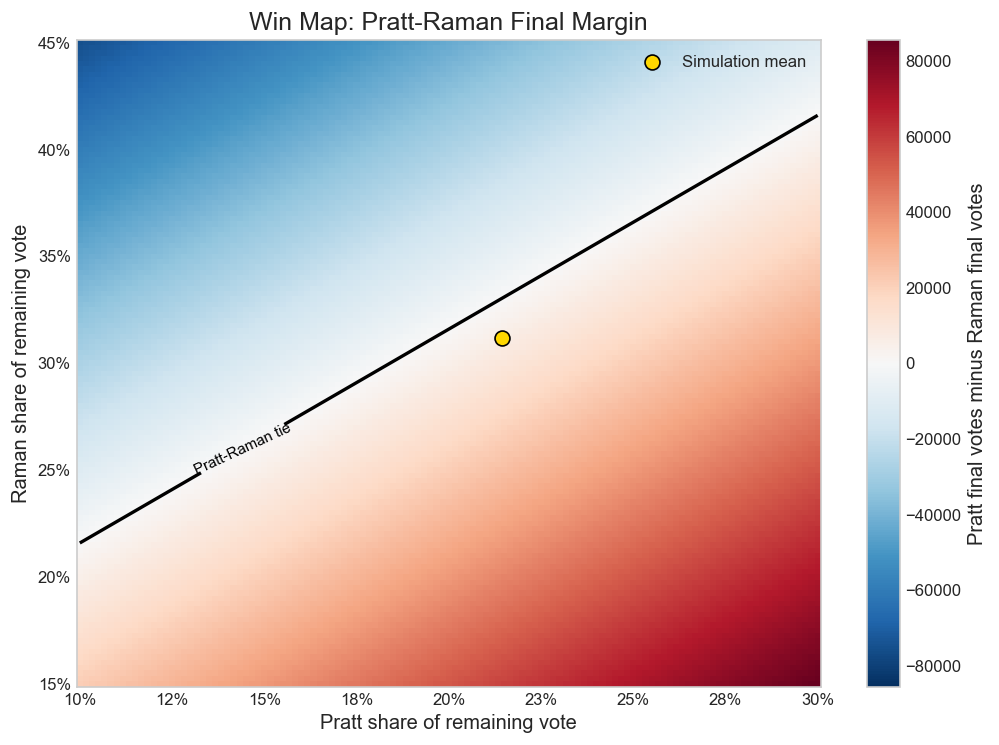

In [11]:
other_fixed = float(simulated_mean_remaining_share["Other"])
pratt_axis = np.linspace(0.10, 0.30, 121)
raman_axis = np.linspace(0.15, 0.45, 121)
margin_grid = np.full((len(raman_axis), len(pratt_axis)), np.nan)
pratt_second_grid = np.full((len(raman_axis), len(pratt_axis)), np.nan)

for i, raman_share in enumerate(raman_axis):
    for j, pratt_share in enumerate(pratt_axis):
        bass_share = 1 - pratt_share - raman_share - other_fixed
        if bass_share < 0:
            continue
        shares = np.array([bass_share, pratt_share, raman_share, other_fixed], dtype=float)
        deterministic_final = current_vote_values + shares * remaining_votes
        deterministic_ranks = pd.Series(deterministic_final, index=candidates).rank(
            ascending=False,
            method="min",
        )
        margin_grid[i, j] = deterministic_final[candidates.index("Pratt")] - deterministic_final[candidates.index("Raman")]
        pratt_second_grid[i, j] = deterministic_ranks["Pratt"] == 2

fig, ax = plt.subplots(figsize=(10, 7))
max_abs_margin = np.nanmax(np.abs(margin_grid))
mesh = ax.pcolormesh(
    pratt_axis,
    raman_axis,
    margin_grid,
    shading="auto",
    cmap="RdBu_r",
    vmin=-max_abs_margin,
    vmax=max_abs_margin,
)
contour = ax.contour(pratt_axis, raman_axis, margin_grid, levels=[0], colors="black", linewidths=2)
ax.clabel(contour, fmt={0: "Pratt-Raman tie"}, inline=True, fontsize=9)
ax.scatter(
    simulated_mean_remaining_share["Pratt"],
    simulated_mean_remaining_share["Raman"],
    s=80,
    color="gold",
    edgecolor="black",
    zorder=3,
    label="Simulation mean",
)

ax.set_title("Win Map: Pratt-Raman Final Margin")
ax.set_xlabel("Pratt share of remaining vote")
ax.set_ylabel("Raman share of remaining vote")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(loc="upper right")
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Pratt final votes minus Raman final votes")
plt.show()

## Scenario Topology

This simplex-like view holds `Other` fixed at the simulation's mean remaining-vote share, varies Bass, Pratt, and Raman across the remaining share, and colors each valid scenario by whether Pratt finishes second.

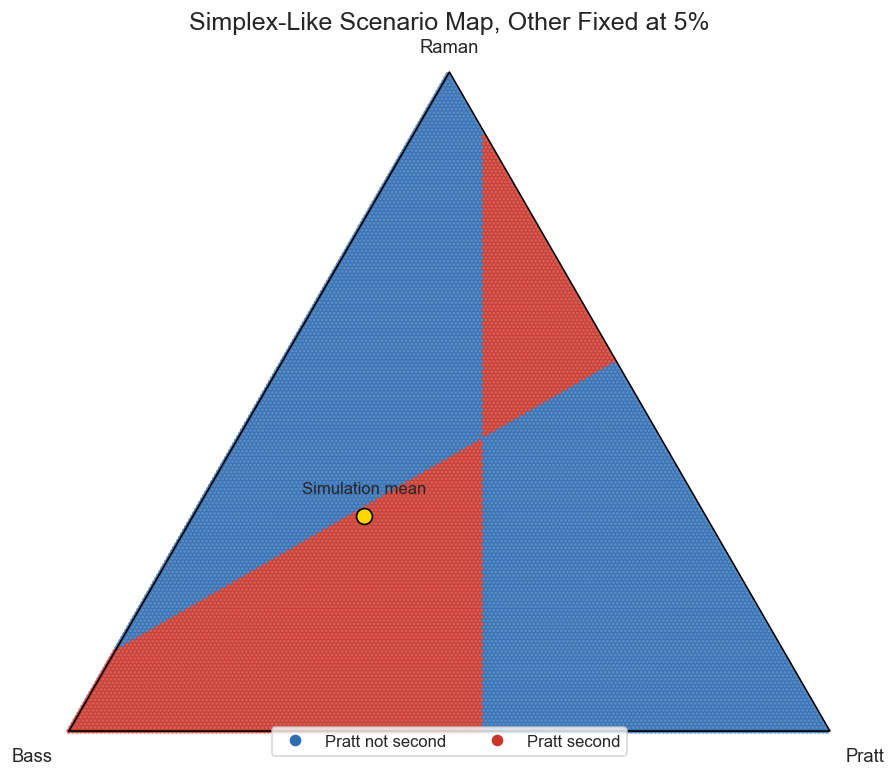

In [12]:
simplex_points = []
share_step = 0.005
available_major_share = 1 - other_fixed

for pratt_share in np.arange(0, available_major_share + share_step / 2, share_step):
    for raman_share in np.arange(0, available_major_share - pratt_share + share_step / 2, share_step):
        bass_share = available_major_share - pratt_share - raman_share
        if bass_share < -1e-10:
            continue
        shares = np.array([bass_share, pratt_share, raman_share, other_fixed], dtype=float)
        deterministic_final = current_vote_values + shares * remaining_votes
        deterministic_ranks = pd.Series(deterministic_final, index=candidates).rank(
            ascending=False,
            method="min",
        )
        simplex_points.append({
            "Bass Share": bass_share,
            "Pratt Share": pratt_share,
            "Raman Share": raman_share,
            "Pratt Finishes Second": deterministic_ranks["Pratt"] == 2,
            "Pratt-Raman Margin": deterministic_final[candidates.index("Pratt")] - deterministic_final[candidates.index("Raman")],
        })

simplex_df = pd.DataFrame(simplex_points)

# Barycentric-style projection with Bass, Pratt, and Raman as triangle vertices.
x = simplex_df["Pratt Share"] + 0.5 * simplex_df["Raman Share"]
y = (np.sqrt(3) / 2) * simplex_df["Raman Share"]

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(
    x,
    y,
    c=simplex_df["Pratt Finishes Second"].astype(int),
    cmap=ListedColormap(["#2F6DB3", "#C9362C"]),
    s=10,
    alpha=0.8,
    linewidths=0,
)

mean_x = simulated_mean_remaining_share["Pratt"] + 0.5 * simulated_mean_remaining_share["Raman"]
mean_y = (np.sqrt(3) / 2) * simulated_mean_remaining_share["Raman"]
ax.scatter(mean_x, mean_y, s=90, color="gold", edgecolor="black", zorder=3)
ax.text(mean_x, mean_y + 0.025, "Simulation mean", ha="center", va="bottom", fontsize=10)

triangle = np.array([
    [0, 0],
    [available_major_share, 0],
    [0.5 * available_major_share, (np.sqrt(3) / 2) * available_major_share],
    [0, 0],
])
ax.plot(triangle[:, 0], triangle[:, 1], color="black", linewidth=1)
ax.text(-0.02, -0.02, "Bass", ha="right", va="top", fontsize=11)
ax.text(available_major_share + 0.02, -0.02, "Pratt", ha="left", va="top", fontsize=11)
ax.text(0.5 * available_major_share, (np.sqrt(3) / 2) * available_major_share + 0.02, "Raman", ha="center", va="bottom", fontsize=11)

ax.set_title(f"Simplex-Like Scenario Map, Other Fixed at {other_fixed:.0%}")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
ax.spines[["left", "right", "top", "bottom"]].set_visible(False)
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="Pratt not second", markerfacecolor="#2F6DB3", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="Pratt second", markerfacecolor="#C9362C", markersize=8),
]
ax.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=True)
plt.show()

## Data Table

This table ties together the observed vote count, aggregate late-vote evidence, derived late/baseline multipliers, selected simulation center, and simulated final outcome.

In [13]:
simulated_mean_final_votes = final_votes.mean()
simulated_median_final_votes = final_votes.median()
simulated_median_final_share = final_votes.div(final_votes.sum(axis=1), axis=0).median()

artifact_table = pd.DataFrame({
    "Candidate": candidates,
    "Current Votes": current_vote_values,
    "Current Share": current_share.reindex(candidates).values,
    "Baseline Share": baseline_share.reindex(candidates).values,
    "Aggregate Late-Vote Share": aggregate_late_vote_share.reindex(candidates).values,
    "Observed Late/Baseline Multiplier": observed_late_multiplier.reindex(candidates).values,
    "Post-Baseline Trend Multiplier": trend_multiplier.reindex(candidates).values,
    "Simulation Center Share": simulation_center_share.reindex(candidates).values,
    "Simulated Mean Remaining Share": simulated_mean_remaining_share.reindex(candidates).values,
    "Simulated Mean Final Votes": simulated_mean_final_votes.reindex(candidates).values,
    "Simulated Median Final Votes": simulated_median_final_votes.reindex(candidates).values,
    "Simulated Median Final Share": simulated_median_final_share.reindex(candidates).values,
})

display(
    artifact_table.style.format({
        "Current Votes": "{:,.0f}",
        "Current Share": "{:.1%}",
        "Baseline Share": "{:.1%}",
        "Aggregate Late-Vote Share": "{:.1%}",
        "Observed Late/Baseline Multiplier": "{:.2f}",
        "Post-Baseline Trend Multiplier": "{:.2f}",
        "Simulation Center Share": "{:.1%}",
        "Simulated Mean Remaining Share": "{:.1%}",
        "Simulated Mean Final Votes": "{:,.0f}",
        "Simulated Median Final Votes": "{:,.0f}",
        "Simulated Median Final Share": "{:.1%}",
    }, na_rep="-")
)

,Candidate,Current Votes,Current Share,Baseline Share,Aggregate Late-Vote Share,Observed Late/Baseline Multiplier,Post-Baseline Trend Multiplier,Simulation Center Share,Simulated Mean Remaining Share,Simulated Mean Final Votes,Simulated Median Final Votes,Simulated Median Final Share
0,Bass,"183,701",35.0%,35.0%,-,-,1.00,42.4%,42.8%,"321,440","320,548",37.8%
1,Pratt,"157,116",29.9%,29.9%,-,-,1.00,22.7%,21.4%,"226,170","225,881",26.7%
2,Raman,"119,809",22.8%,22.8%,-,-,1.00,30.0%,31.2%,"220,128","216,771",25.6%
3,Other,"64,700",12.3%,12.3%,-,-,1.00,5.0%,4.6%,"79,561","79,526",9.4%
